# Forecasting de Producción Mensual de Cerveza en EE.UU. (Barriles)

**Materia:** Series Temporales — Maestría en Ciencias de la Inteligencia Artificial
**Universidad:** Universidad Nacional de Asunción (FIUNA)
**Profesores:** Dr. Diego Stalder — Msc. Enrique Paiva

**Integrantes:**
- Daira Pérez (Ingeniera de Alimentos)
- Malena Russo (Ingeniera Química)

**Fecha:** Julio 2026

---

## Descripción del problema

La industria cervecera de EE.UU. reporta mensualmente su producción total ante la
*Alcohol and Tobacco Tax and Trade Bureau (TTB)*. En este proyecto se busca predecir
la **producción mensual de cerveza, medida en barriles**, a nivel nacional. Contar con
una predicción confiable permite anticipar necesidades de insumos (malta, lúpulo,
cereales), planificar logística de distribución y dimensionar la capacidad productiva
del sector.

## Dataset

**Fuente:** [Beer Production — Kaggle (jessemostipak)](https://www.kaggle.com/datasets/jessemostipak/beer-production)
**Origen original:** Alcohol and Tobacco Tax and Trade Bureau (TTB), vía TidyTuesday (2020-03-31)
**Licencia:** CC0 Public Domain
**Archivo utilizado:** `beer_taxed.csv`
**Frecuencia:** Mensual, 2008–2019 (144 observaciones)
**Variable objetivo:** Barriles producidos por mes (`type='Production'`, `tax_status='Totals'`)

## Bloque 1: Carga de librerías y datos

Importamos las librerías necesarias para manejo de datos, visualización y análisis
de series de tiempo (`pandas`, `numpy`, `matplotlib`, `seaborn`, `statsmodels`).
Luego cargamos el dataset `beer_taxed.csv` y verificamos su estructura (columnas,
cantidad de filas) para confirmar que la carga fue exitosa.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

url_datos = "https://raw.githubusercontent.com/dperez-prog/proyecto-series-temporales-cerveza/main/data/beer_taxed.csv"

df_raw = pd.read_csv(url_datos)

print("Dimensiones:", df_raw.shape)
df_raw.head()

Dimensiones: (1580, 10)


,data_type,tax_status,year,month,type,month_current,month_prior_year,ytd_current,ytd_prior_year,tax_rate
0,Barrels Produced,Totals,2008,1,Production,16211480,15880125,16211480.0,15880125.0,$7/$18 per barrel
1,Barrels Produced,Taxable,2008,1,In bottles and cans,13222104,12824278,13222104.0,12824278.0,$7/$18 per barrel
2,Barrels Produced,Taxable,2008,1,In barrels and kegs,1371239,1357372,1371239.0,1357372.0,$7/$18 per barrel
3,Barrels Produced,Taxable,2008,1,"Tax Determined, Premises Use",7426,8419,7426.0,8419.0,$7/$18 per barrel
4,Barrels Produced,Sub Total Taxable,2008,1,Sub Total Taxable,14600769,14190069,14600769.0,14190069.0,$7/$18 per barrel


## Bloque 2: Filtrado de la serie de producción y construcción del índice temporal

Del dataset completo, filtramos únicamente las filas correspondientes a
`tax_status == 'Totals'` y `type == 'Production'`, que representan la producción
total mensual de cerveza en barriles. Convertimos las columnas `year` y `month`
en una columna de fecha (`date`) para tratar la serie como una serie de tiempo
correctamente indexada.

In [ ]:
# Filtrar la producción total mensual
df_prod = df_raw[
    (df_raw['tax_status'] == 'Totals') &
    (df_raw['type'] == 'Production')
].copy()

# Construir columna de fecha
df_prod['date'] = pd.to_datetime(
    df_prod['year'].astype(str) + '-' + df_prod['month'].astype(str) + '-01'
)

# Ordenar y setear índice temporal
df_prod = df_prod.sort_values('date').set_index('date')

# Quedarnos con la serie de interés (barriles producidos ese mes)
serie_produccion = df_prod['month_current']

print("Rango de fechas:", serie_produccion.index.min(), "-", serie_produccion.index.max())
print("Cantidad de observaciones:", len(serie_produccion))
print("Valores nulos:", serie_produccion.isnull().sum())
serie_produccion.head()

Rango de fechas: 2008-01-01 00:00:00 - 2019-12-01 00:00:00
Cantidad de observaciones: 144
Valores nulos: 0


,month_current
date,
2008-01-01,16211480
2008-02-01,15690494
2008-03-01,17367476
2008-04-01,17254160
2008-05-01,18269043


## Bloque 3: Visualización de la serie temporal

Graficamos la serie de producción mensual de cerveza para observar visualmente
su tendencia y estacionalidad a lo largo de los 12 años de historial disponible.

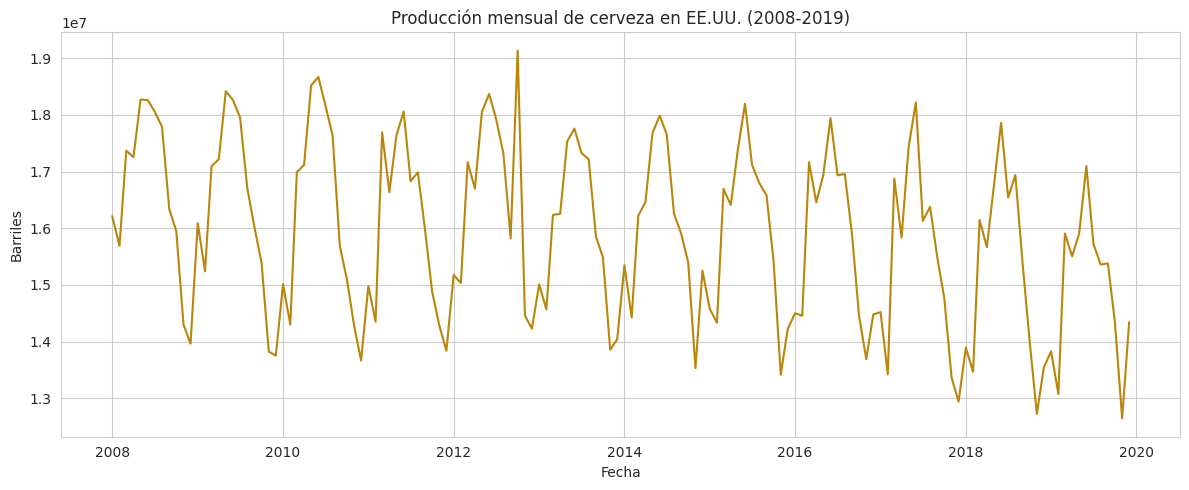

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(serie_produccion.index, serie_produccion.values, color='#B8860B', linewidth=1.5)
plt.title('Producción mensual de cerveza en EE.UU. (2008-2019)')
plt.xlabel('Fecha')
plt.ylabel('Barriles')
plt.tight_layout()
plt.show()

## Bloque 4: Test de estacionariedad (ADF) y descomposición de la serie

Aplicamos el test de Dickey-Fuller aumentado (ADF) para evaluar si la serie es
estacionaria en su forma original. Adicionalmente, descomponemos la serie en sus
componentes de tendencia, estacionalidad y residuo, para visualizar por separado
cada patrón detectado.

Estadístico ADF: -0.2752
p-valor: 0.9289
Valores críticos:
   1%: -3.4817
   5%: -2.8840
   10%: -2.5788

→ No se rechaza H0: la serie NO es estacionaria (requiere diferenciación)


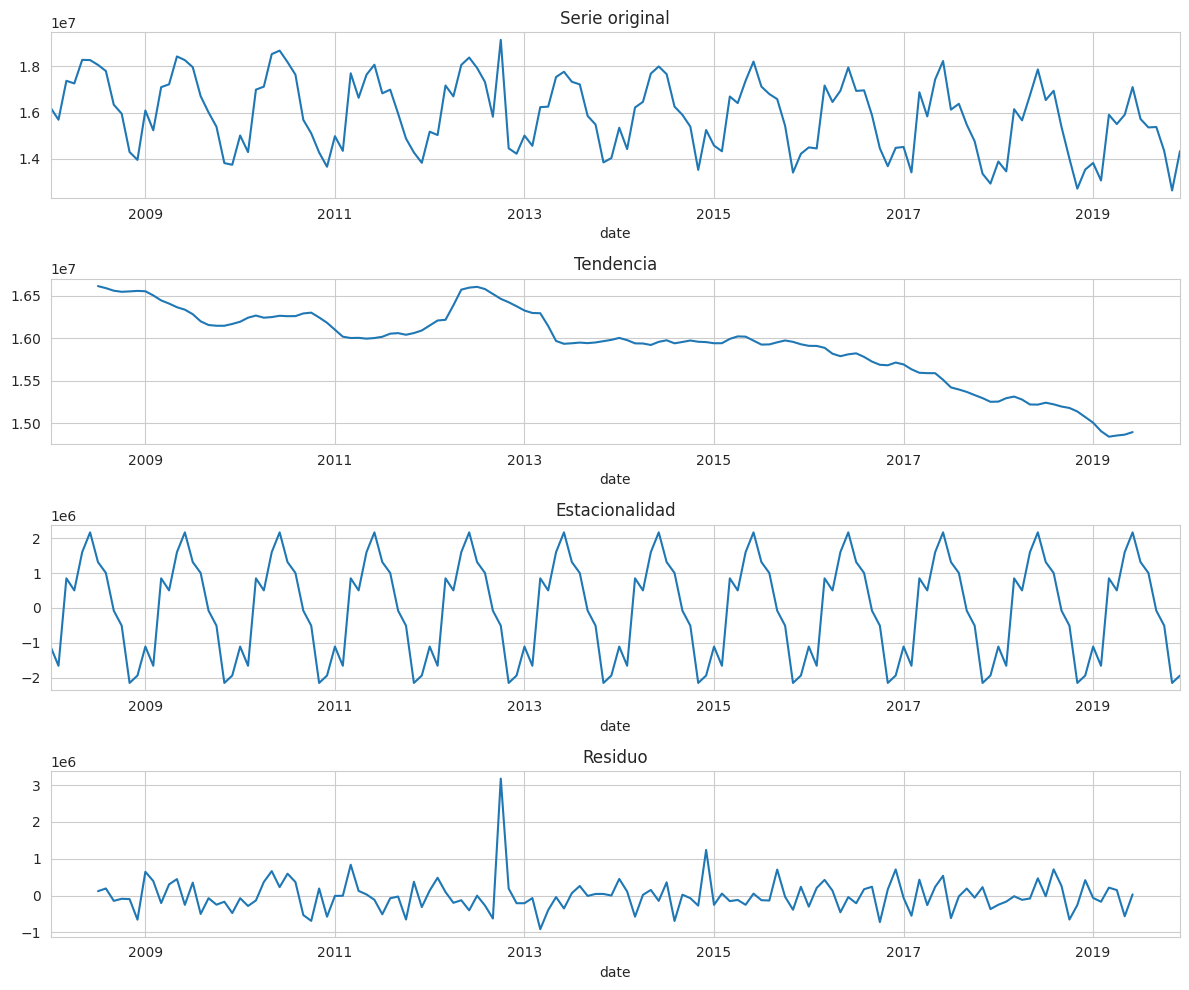

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Test de Dickey-Fuller aumentado
resultado_adf = adfuller(serie_produccion)
print(f"Estadístico ADF: {resultado_adf[0]:.4f}")
print(f"p-valor: {resultado_adf[1]:.4f}")
print("Valores críticos:")
for key, value in resultado_adf[4].items():
    print(f"   {key}: {value:.4f}")

if resultado_adf[1] < 0.05:
    print("\n→ Se rechaza H0: la serie ES estacionaria")
else:
    print("\n→ No se rechaza H0: la serie NO es estacionaria (requiere diferenciación)")

# Descomposición de la serie (aditiva, período 12 = mensual)
descomposicion = seasonal_decompose(serie_produccion, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))
descomposicion.observed.plot(ax=axes[0], title='Serie original')
descomposicion.trend.plot(ax=axes[1], title='Tendencia')
descomposicion.seasonal.plot(ax=axes[2], title='Estacionalidad')
descomposicion.resid.plot(ax=axes[3], title='Residuo')
plt.tight_layout()
plt.show()

## Bloque 5: Diferenciación para lograr estacionariedad

Dado que el test ADF confirmó que la serie no es estacionaria, aplicamos
diferenciación estacional (lag=12, para remover el ciclo anual) y luego
diferenciación regular (lag=1, para remover la tendencia remanente).
Verificamos con un nuevo test ADF si la serie resultante ya es estacionaria.

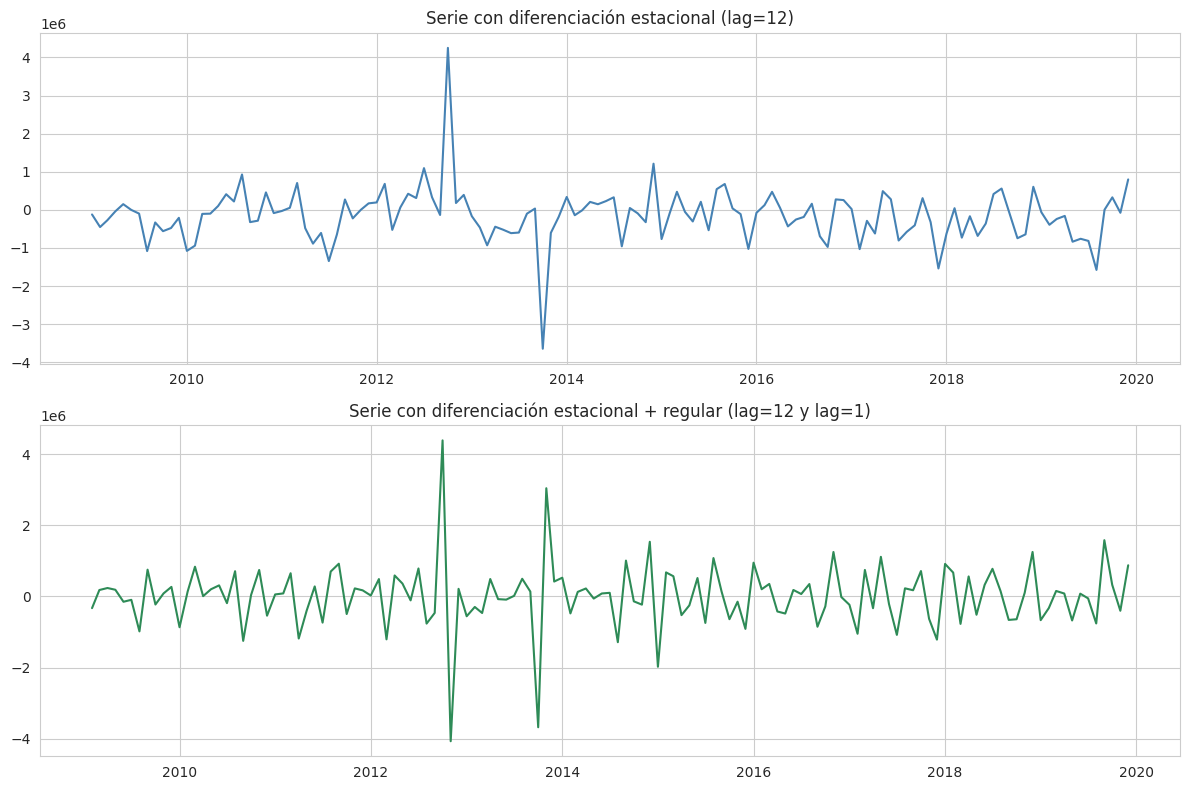

Estadístico ADF: -4.9437
p-valor: 0.0000

→ Se rechaza H0: la serie diferenciada ES estacionaria ✓


In [ ]:
# Diferenciación estacional (elimina el ciclo anual, lag=12)
serie_diff_estacional = serie_produccion.diff(12).dropna()

# Diferenciación regular adicional (elimina tendencia remanente, lag=1)
serie_diff_completa = serie_diff_estacional.diff(1).dropna()

# Graficar ambas series diferenciadas
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(serie_diff_estacional.index, serie_diff_estacional.values, color='#4682B4')
axes[0].set_title('Serie con diferenciación estacional (lag=12)')
axes[1].plot(serie_diff_completa.index, serie_diff_completa.values, color='#2E8B57')
axes[1].set_title('Serie con diferenciación estacional + regular (lag=12 y lag=1)')
plt.tight_layout()
plt.show()

# Test ADF sobre la serie completamente diferenciada
resultado_adf_2 = adfuller(serie_diff_completa)
print(f"Estadístico ADF: {resultado_adf_2[0]:.4f}")
print(f"p-valor: {resultado_adf_2[1]:.4f}")

if resultado_adf_2[1] < 0.05:
    print("\n→ Se rechaza H0: la serie diferenciada ES estacionaria ✓")
else:
    print("\n→ Aún no es estacionaria, requiere diferenciación adicional")

## Bloque 6: Funciones de autocorrelación (ACF) y autocorrelación parcial (PACF)

Sobre la serie ya estacionaria (diferenciada estacional + regularmente), graficamos
la ACF y PACF para identificar los órdenes candidatos de los componentes
autorregresivo (AR) y de media móvil (MA), tanto en su versión regular como
estacional, que utilizaremos para configurar el modelo SARIMA.

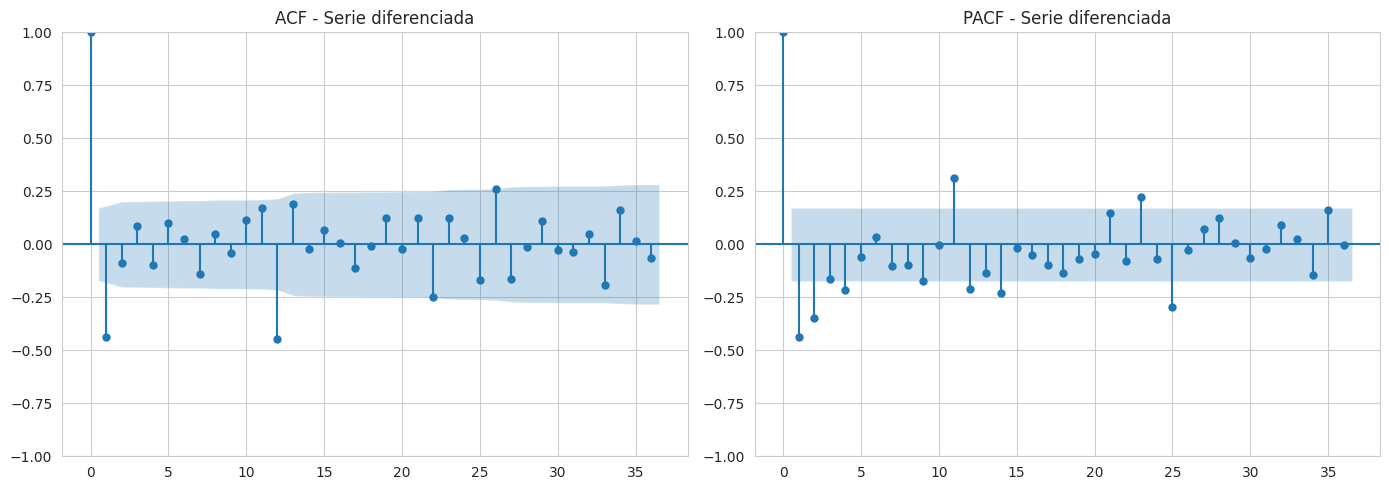

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(serie_diff_completa, lags=36, ax=axes[0])
axes[0].set_title('ACF - Serie diferenciada')

plot_pacf(serie_diff_completa, lags=36, ax=axes[1])
axes[1].set_title('PACF - Serie diferenciada')

plt.tight_layout()
plt.show()

## Bloque 7: División en conjunto de entrenamiento y prueba

Dividimos la serie en entrenamiento y prueba, respetando el orden temporal
(sin mezclar aleatoriamente). Se reservan los últimos 12 meses como conjunto
de prueba, para evaluar la capacidad de pronóstico a un horizonte de un año.

Entrenamiento: 2008-01-01 00:00:00 - 2018-12-01 00:00:00 (132 obs)
Prueba: 2019-01-01 00:00:00 - 2019-12-01 00:00:00 (12 obs)


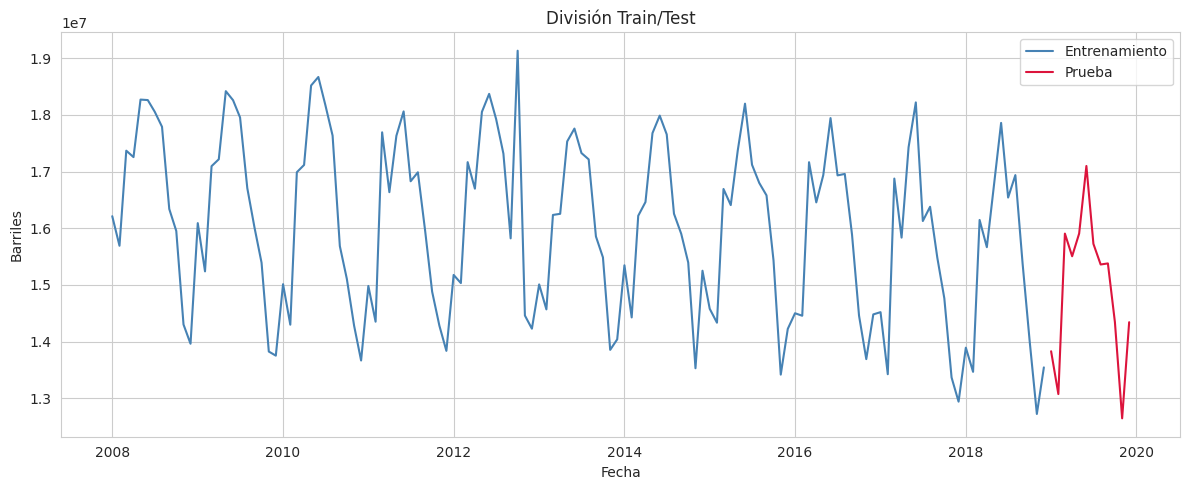

In [ ]:
# Reservamos los últimos 12 meses como test
n_test = 12
train = serie_produccion.iloc[:-n_test]
test = serie_produccion.iloc[-n_test:]

print("Entrenamiento:", train.index.min(), "-", train.index.max(), f"({len(train)} obs)")
print("Prueba:", test.index.min(), "-", test.index.max(), f"({len(test)} obs)")

plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, label='Entrenamiento', color='#4682B4')
plt.plot(test.index, test.values, label='Prueba', color='#DC143C')
plt.title('División Train/Test')
plt.xlabel('Fecha')
plt.ylabel('Barriles')
plt.legend()
plt.tight_layout()
plt.show()

## Bloque 8: Entrenamiento del modelo SARIMA

Entrenamos un modelo SARIMA(0,1,1)(0,1,1)_12, cuyos órdenes fueron definidos
a partir del análisis de ACF/PACF del Bloque 6 (patrón característico del
"modelo Airline" de Box-Jenkins: diferenciación regular y estacional, con un
único término de media móvil en cada nivel). El modelo se ajusta únicamente
sobre el conjunto de entrenamiento (2008-2018).

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Definir y entrenar el modelo SARIMA
modelo_sarima = SARIMAX(
    train,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultado_sarima = modelo_sarima.fit(disp=False)

# Resumen del modelo
print(resultado_sarima.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                      month_current   No. Observations:                  132
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -1564.506
Date:                            Tue, 21 Jul 2026   AIC                           3135.012
Time:                                    02:41:42   BIC                           3142.974
Sample:                                01-01-2008   HQIC                          3138.238
                                     - 12-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7060      0.084     -8.385      0.000      -0.871      -0.541
ma.S.L12      -0.2870      0.049   

## Bloque 8.5: Corrección de frecuencia del índice temporal

Se fija explícitamente la frecuencia mensual (`MS`) del índice para evitar
advertencias de statsmodels y garantizar la correcta generación de fechas
futuras al pronosticar.

In [ ]:
train = train.asfreq('MS')
test = test.asfreq('MS')

modelo_sarima = SARIMAX(
    train,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
resultado_sarima = modelo_sarima.fit(disp=False)
print(resultado_sarima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      month_current   No. Observations:                  132
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -1564.506
Date:                            Tue, 21 Jul 2026   AIC                           3135.012
Time:                                    02:41:44   BIC                           3142.974
Sample:                                01-01-2008   HQIC                          3138.238
                                     - 12-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7060      0.084     -8.385      0.000      -0.871      -0.541
ma.S.L12      -0.2870      0.049   

## Bloque 9: Diagnóstico de residuales del modelo SARIMA

Analizamos los residuales del modelo mediante los gráficos de diagnóstico
estándar de statsmodels: serie de residuales en el tiempo, histograma con
curva normal de referencia, gráfico Q-Q y correlograma (ACF). Esto permite
verificar si el modelo capturó adecuadamente la estructura de la serie o
si aún queda información sin explicar (por ejemplo, el outlier detectado
en 2012-2013).

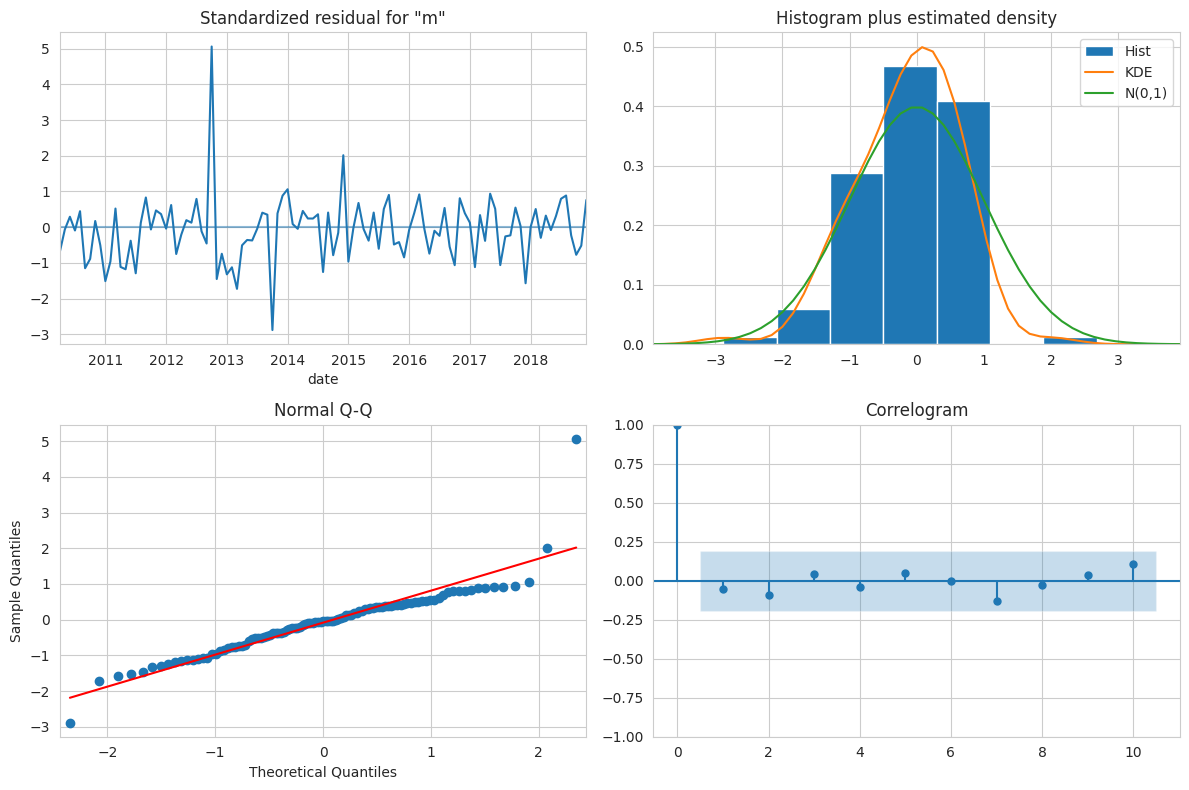

In [ ]:
resultado_sarima.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

## Conclusión: Diagnóstico de residuales

El correlograma no muestra autocorrelación significativa, confirmando que el
modelo SARIMA(0,1,1)(0,1,1)_12 capturó correctamente la estructura de la serie.
Los residuales presentan colas más pesadas que una distribución normal, debido
a un valor atípico puntual en 2012-2013 (Jarque-Bera=411.27, Kurtosis=12.28).
Esto se documenta como limitación conocida, sin invalidar el uso del modelo
para pronosticar.

## Bloque 10: Pronóstico sobre el conjunto de prueba

Utilizamos el modelo entrenado para generar el pronóstico de los 12 meses
del conjunto de prueba (2019), junto con su intervalo de confianza del 95%.
Comparamos visualmente el pronóstico contra los valores reales.

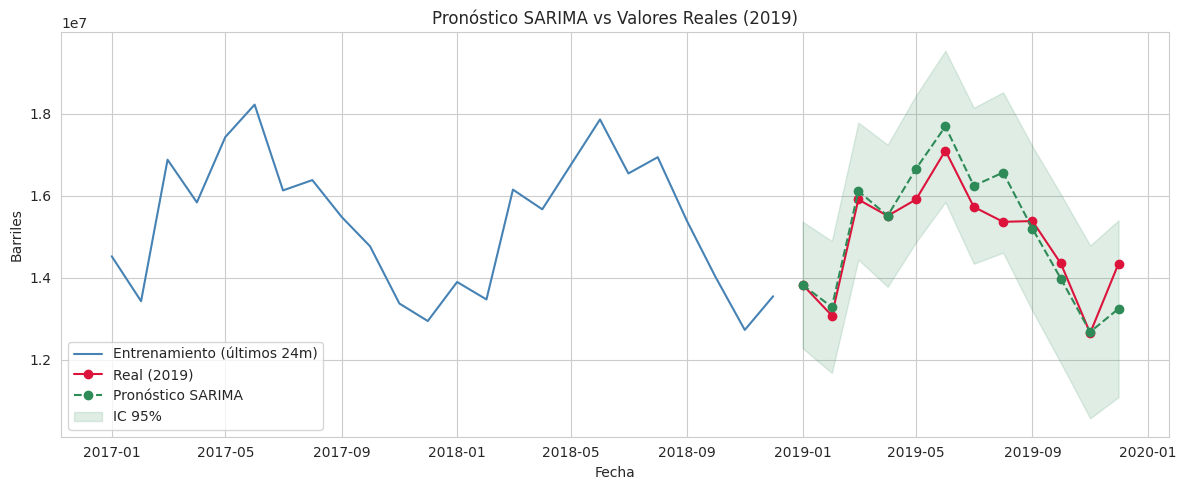

In [ ]:
# Pronóstico para el horizonte de test (12 meses)
pronostico = resultado_sarima.get_forecast(steps=n_test)
pred_media = pronostico.predicted_mean
pred_ic = pronostico.conf_int(alpha=0.05)

# Gráfico comparativo
plt.figure(figsize=(12, 5))
plt.plot(train.index[-24:], train.values[-24:], label='Entrenamiento (últimos 24m)', color='#4682B4')
plt.plot(test.index, test.values, label='Real (2019)', color='#DC143C', marker='o')
plt.plot(pred_media.index, pred_media.values, label='Pronóstico SARIMA', color='#2E8B57', marker='o', linestyle='--')
plt.fill_between(pred_ic.index, pred_ic.iloc[:, 0], pred_ic.iloc[:, 1], color='#2E8B57', alpha=0.15, label='IC 95%')
plt.title('Pronóstico SARIMA vs Valores Reales (2019)')
plt.xlabel('Fecha')
plt.ylabel('Barriles')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusión: Pronóstico SARIMA vs valores reales (2019)

El modelo SARIMA logra capturar correctamente la forma estacional de la serie,
replicando los picos (mitad de año) y valles (fin de año) observados en los
valores reales de 2019. Los valores reales caen dentro del intervalo de
confianza del 95% en la gran mayoría de los meses, aunque se observa una
leve sobreestimación en abril-mayo y una subestimación en octubre. El error
puntual se cuantifica en el siguiente bloque mediante RMSE, MAE y MAPE.

## Bloque 11: Métricas de evaluación (SARIMA)

Calculamos las métricas obligatorias de evaluación (RMSE, MAE, MAPE) comparando
el pronóstico del modelo SARIMA contra los valores reales del conjunto de prueba.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

rmse_sarima = np.sqrt(mean_squared_error(test, pred_media))
mae_sarima = mean_absolute_error(test, pred_media)
mape_sarima = mean_absolute_percentage_error(test, pred_media) * 100

print(f"RMSE: {rmse_sarima:,.0f} barriles")
print(f"MAE:  {mae_sarima:,.0f} barriles")
print(f"MAPE: {mape_sarima:.2f}%")

RMSE: 583,913 barriles
MAE:  430,181 barriles
MAPE: 2.82%


## Bloque 12: Ingeniería de atributos para XGBoost

A diferencia de SARIMA, un modelo de Machine Learning como XGBoost no entiende
el concepto de "serie temporal" de forma nativa: necesita atributos (features)
explícitos como input. Construimos:
- **Variables de calendario:** mes y trimestre, para capturar la estacionalidad.
- **Variables de rezago (lags):** valores de la serie en t-1, t-2, t-3 y t-12,
  que le permiten al modelo "ver" el pasado reciente y el mismo mes del año anterior.

Es importante generar estos atributos usando únicamente información disponible
hasta el momento de la predicción, para evitar fuga de datos (data leakage).

### Entrenamiento de XGBoost sin utilizar el test


In [ ]:
from xgboost import XGBRegressor

# Rezagos definidos antes de evaluar el test:
# corto plazo (1, 2, 3 meses) y estacionalidad anual (12 meses)
lags_xgb = [1, 2, 3, 12]

# Crear atributos únicamente con el conjunto de entrenamiento
df_xgb_train = train.to_frame(name='barriles')

df_xgb_train['mes'] = df_xgb_train.index.month
df_xgb_train['trimestre'] = df_xgb_train.index.quarter

for lag in lags_xgb:
    df_xgb_train[f'lag_{lag}'] = df_xgb_train['barriles'].shift(lag)

df_xgb_train = df_xgb_train.dropna()

X_train_xgb = df_xgb_train.drop(columns='barriles')
y_train_xgb = df_xgb_train['barriles']

modelo_xgb_final = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    objective='reg:squarederror',
    random_state=42
)

modelo_xgb_final.fit(X_train_xgb, y_train_xgb)

print("XGBoost entrenado sin utilizar datos de 2019")
print("Observaciones de entrenamiento:", len(X_train_xgb))

XGBoost entrenado sin utilizar datos de 2019
Observaciones de entrenamiento: 120


## Bloque 13: Pronóstico recursivo de XGBoost

En este bloque se implementa el **pronóstico recursivo** de XGBoost para los 12 meses de 2019. A diferencia de la predicción directa sobre `X_test`, aquí el modelo nunca accede a los valores reales de 2019: parte del historial disponible hasta diciembre de 2018 y, en cada paso, utiliza su propia predicción del mes anterior como insumo para predecir el siguiente. Esto garantiza que la comparación con SARIMA sea justa, ya que ambos modelos conocen únicamente información hasta diciembre de 2018 al momento de pronosticar.

In [ ]:
# Historial disponible hasta diciembre de 2018
historial = list(train.astype(float).values)

predicciones_xgb = []

for fecha in test.index:
    fila = {
        'mes': fecha.month,
        'trimestre': fecha.quarter,
        'lag_1': historial[-1],
        'lag_2': historial[-2],
        'lag_3': historial[-3],
        'lag_12': historial[-12]
    }

    X_futuro = pd.DataFrame([fila], index=[fecha])
    X_futuro = X_futuro[X_train_xgb.columns]

    prediccion = modelo_xgb_final.predict(X_futuro)[0]

    predicciones_xgb.append(prediccion)

    # Se agrega la predicción, no el valor real del test
    historial.append(prediccion)

pred_xgb_final = pd.Series(
    predicciones_xgb,
    index=test.index,
    name='Pronóstico XGBoost'
)

pred_xgb_final

,Pronóstico XGBoost
date,
2019-01-01,14520032.0
2019-02-01,13478408.0
2019-03-01,16261945.0
2019-04-01,15029838.0
2019-05-01,16934254.0
2019-06-01,17582854.0
2019-07-01,16497305.0
2019-08-01,16829764.0
2019-09-01,15164172.0


## Bloque 14: Métricas y comparación final

In [ ]:
rmse_xgb_final = np.sqrt(mean_squared_error(test, pred_xgb_final))
mae_xgb_final = mean_absolute_error(test, pred_xgb_final)
mape_xgb_final = mean_absolute_percentage_error(
    test, pred_xgb_final
) * 100

comparacion_final = pd.DataFrame({
    'Modelo': [
        'SARIMA(0,1,1)(0,1,1)_12',
        'XGBoost recursivo (lags 1-3 y 12)'
    ],
    'RMSE': [
        rmse_sarima,
        rmse_xgb_final
    ],
    'MAE': [
        mae_sarima,
        mae_xgb_final
    ],
    'MAPE (%)': [
        mape_sarima,
        mape_xgb_final
    ]
})

print(comparacion_final.to_string(index=False))

                           Modelo          RMSE           MAE  MAPE (%)
          SARIMA(0,1,1)(0,1,1)_12 583912.765356 430181.425435   2.82387
XGBoost recursivo (lags 1-3 y 12) 725633.682129 640816.562500   4.29191


## Bloque 15: Predicciones frente a valores reales





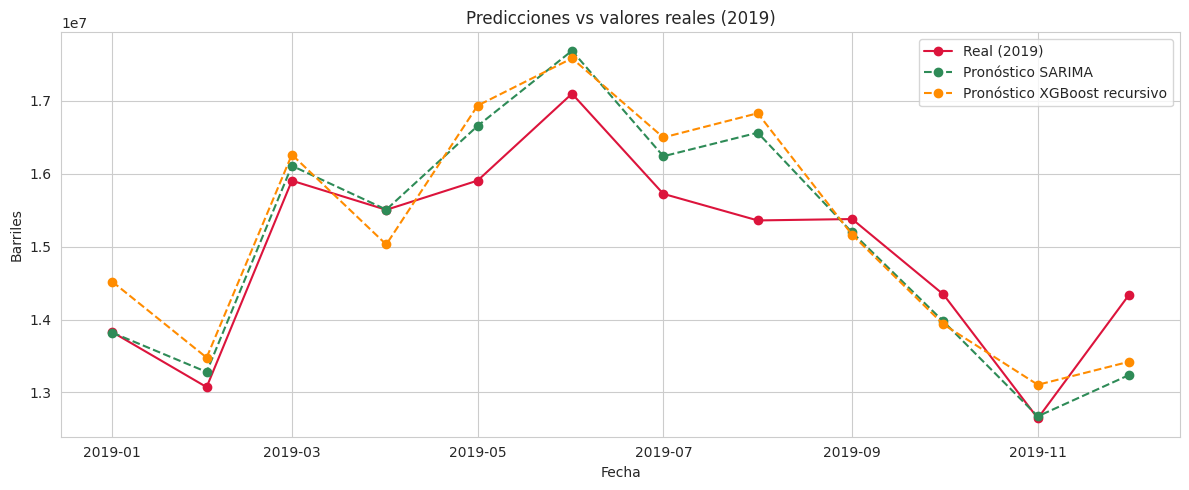

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    test.index,
    test.values,
    label='Real (2019)',
    color='#DC143C',
    marker='o'
)

plt.plot(
    pred_media.index,
    pred_media.values,
    label='Pronóstico SARIMA',
    color='#2E8B57',
    marker='o',
    linestyle='--'
)

plt.plot(
    pred_xgb_final.index,
    pred_xgb_final.values,
    label='Pronóstico XGBoost recursivo',
    color='#FF8C00',
    marker='o',
    linestyle='--'
)

plt.title('Predicciones vs valores reales (2019)')
plt.xlabel('Fecha')
plt.ylabel('Barriles')
plt.legend()
plt.tight_layout()
plt.show()

## Bloque 16: Análisis del error por horizonte

Calculamos el error absoluto de cada modelo para los 12 meses del conjunto de
prueba. Como ambos pronósticos se generan desde diciembre de 2018 sin utilizar
valores reales de 2019, los meses representan correctamente los horizontes
h=1 hasta h=12.

    Mes  Horizonte (h)  Error SARIMA  Error XGBoost
2019-01              1  7.707594e+03       691252.0
2019-02              2  2.075558e+05       404530.0
2019-03              3  2.039456e+05       357006.0
2019-04              4  2.531496e+03       475341.0
2019-05              5  7.493587e+05      1028231.0
2019-06              6  5.893177e+05       485057.0
2019-07              7  5.153687e+05       773015.0
2019-08              8  1.203007e+06      1470071.0
2019-09              9  1.836854e+05       214511.0
2019-10             10  3.702123e+05       410716.0
2019-11             11  2.791084e+04       460407.0
2019-12             12  1.101576e+06       919661.0


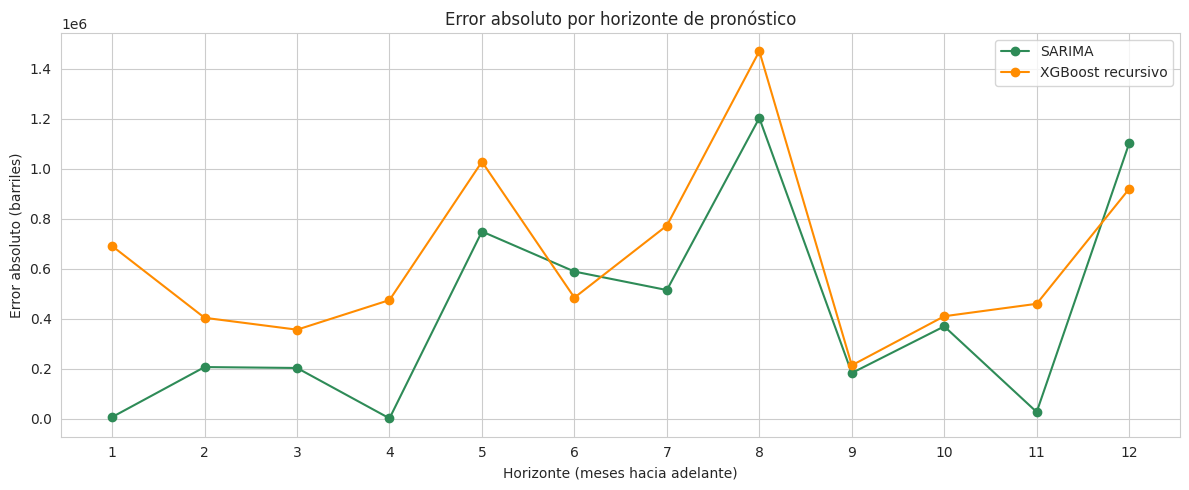

In [ ]:
# Error absoluto de cada modelo
errores_sarima = np.abs(test.values - pred_media.values)
errores_xgb = np.abs(test.values - pred_xgb_final.values)

df_errores = pd.DataFrame({
    'Mes': test.index.strftime('%Y-%m'),
    'Horizonte (h)': range(1, len(test) + 1),
    'Error SARIMA': errores_sarima,
    'Error XGBoost': errores_xgb
})

print(df_errores.to_string(index=False))

# Visualización del error por horizonte
plt.figure(figsize=(12, 5))

plt.plot(
    df_errores['Horizonte (h)'],
    df_errores['Error SARIMA'],
    marker='o',
    label='SARIMA',
    color='#2E8B57'
)

plt.plot(
    df_errores['Horizonte (h)'],
    df_errores['Error XGBoost'],
    marker='o',
    label='XGBoost recursivo',
    color='#FF8C00'
)

plt.title('Error absoluto por horizonte de pronóstico')
plt.xlabel('Horizonte (meses hacia adelante)')
plt.ylabel('Error absoluto (barriles)')
plt.xticks(range(1, len(test) + 1))
plt.legend()
plt.tight_layout()

plt.savefig(
    'error_por_horizonte.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

### Conclusión del análisis por horizonte

El error no aumenta de forma monotónica con el horizonte de pronóstico. Ambos
modelos presentan su mayor dificultad en agosto de 2019 (h=8), lo que sugiere
un comportamiento mensual particularmente difícil de anticipar. SARIMA obtuvo
un error absoluto menor que XGBoost en 10 de los 12 meses evaluados, consistente
con sus mejores resultados agregados de RMSE, MAE y MAPE.

## Bloque 17: Comparación visual de los modelos

Comparamos las métricas RMSE, MAE y MAPE obtenidas por SARIMA y XGBoost
recursivo sobre el mismo conjunto de prueba y horizonte de pronóstico.
En las tres métricas, un valor menor indica un mejor desempeño.

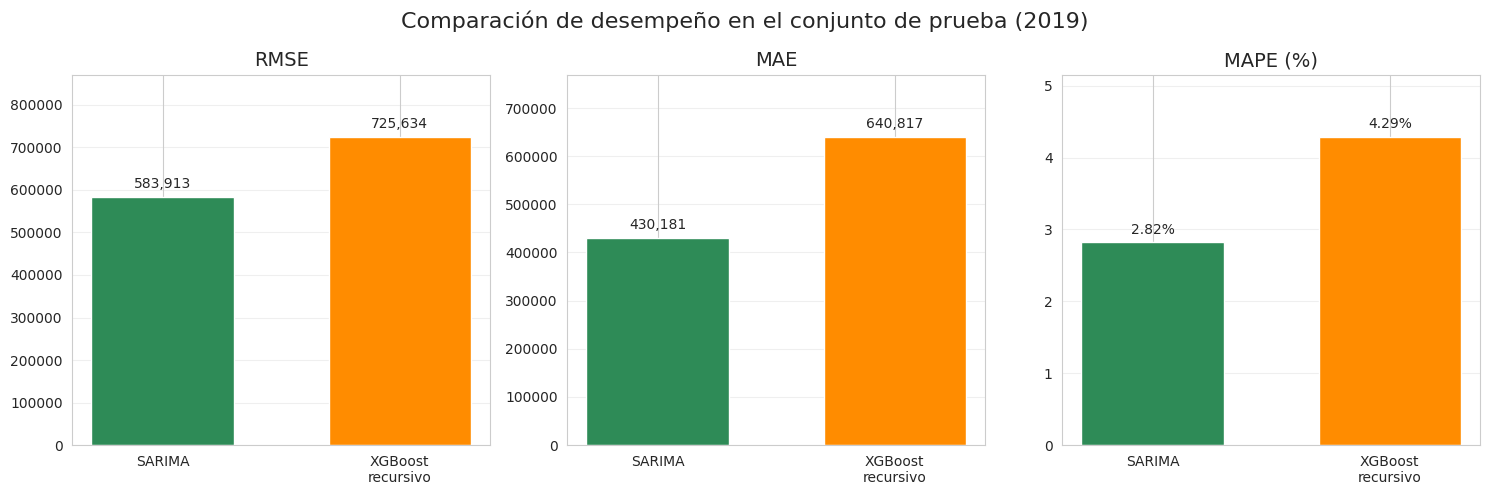

In [ ]:
# Nombres más cortos para el gráfico
nombres_modelos = ['SARIMA', 'XGBoost\nrecursivo']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metricas = ['RMSE', 'MAE', 'MAPE (%)']
colores = ['#2E8B57', '#FF8C00']

for i, metrica in enumerate(metricas):
    valores = comparacion_final[metrica].values

    barras = axes[i].bar(
        nombres_modelos,
        valores,
        color=colores,
        width=0.6
    )

    axes[i].set_title(metrica, fontsize=14)
    axes[i].set_ylim(0, max(valores) * 1.20)
    axes[i].grid(axis='y', alpha=0.3)

    # Etiquetas encima de las barras
    if metrica == 'MAPE (%)':
        etiquetas = [f'{valor:.2f}%' for valor in valores]
    else:
        etiquetas = [f'{valor:,.0f}' for valor in valores]

    axes[i].bar_label(
        barras,
        labels=etiquetas,
        padding=4,
        fontsize=10
    )

fig.suptitle(
    'Comparación de desempeño en el conjunto de prueba (2019)',
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    'comparacion_modelos.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

### Resultado de la comparación

SARIMA superó a XGBoost recursivo en las tres métricas. El modelo estadístico
obtuvo un MAPE de 2,82%, frente al 4,29% de XGBoost, además de presentar menores
valores de RMSE y MAE. Esto indica que SARIMA fue el modelo más preciso para esta
serie mensual, caracterizada por una estacionalidad anual marcada y un número
moderado de observaciones.

## Bloque 18: Conclusiones finales

### Resultados principales

| Modelo | RMSE (barriles) | MAE (barriles) | MAPE |
|---|---:|---:|---:|
| SARIMA(0,1,1)(0,1,1)₁₂ | 583.913 | 430.181 | 2,82% |
| XGBoost recursivo (lags 1-3 y 12) | 725.634 | 640.817 | 4,29% |

### Conclusiones

1. **SARIMA obtuvo el mejor desempeño** en las tres métricas de evaluación.
   Su MAPE de 2,82% fue inferior al 4,29% obtenido por XGBoost recursivo.

2. **La estacionalidad anual de la producción cervecera fue capturada
   adecuadamente por SARIMA**, mediante la diferenciación estacional y el
   componente de media móvil con período de 12 meses.

3. **La comparación se realizó sin fuga de datos.** Ambos modelos fueron
   entrenados exclusivamente con información disponible hasta diciembre de
   2018 y pronosticaron los 12 meses de 2019 sin utilizar sus valores reales
   como predictores.

4. **SARIMA presentó menor error en 10 de los 12 meses evaluados.** Ambos
   modelos registraron su mayor error en agosto de 2019, indicando que ese
   mes fue particularmente difícil de anticipar.

5. **Un modelo más complejo no garantiza mayor precisión.** Para una serie
   mensual con estacionalidad marcada y un número moderado de observaciones,
   el modelo estadístico clásico superó al modelo de Machine Learning.

### Limitaciones

- El dataset contiene únicamente 144 observaciones mensuales.
- La evaluación final se realizó sobre un único período de 12 meses.
- Los residuales de SARIMA presentan desviaciones de la normalidad asociadas
  principalmente a valores atípicos de 2012-2013.
- XGBoost se evaluó con una configuración fija de hiperparámetros, sin realizar
  una búsqueda exhaustiva para evitar utilizar el conjunto de prueba durante
  la selección del modelo.
- Al tratarse de un pronóstico recursivo, los errores de XGBoost pueden
  propagarse de un mes al siguiente.

### Conclusión general

Para la producción mensual de cerveza en Estados Unidos, SARIMA fue el modelo
más preciso y adecuado entre los evaluados. Su capacidad para representar
directamente la tendencia y la estacionalidad anual permitió obtener mejores
pronósticos que XGBoost sobre el conjunto de prueba de 2019.

## Bloque 19: Exportación de resultados

Exportamos las métricas, los errores por horizonte y las principales
visualizaciones utilizadas en el proyecto. Los archivos se agrupan en un ZIP
para facilitar su incorporación a la carpeta `results` del repositorio.

In [ ]:
import os
import zipfile
from google.colab import files

# ============================================================
# 1. Exportar tablas
# ============================================================

metricas_exportar = comparacion_final.copy()
metricas_exportar['RMSE'] = metricas_exportar['RMSE'].round(2)
metricas_exportar['MAE'] = metricas_exportar['MAE'].round(2)
metricas_exportar['MAPE (%)'] = metricas_exportar['MAPE (%)'].round(4)

metricas_exportar.to_csv(
    'metricas.csv',
    index=False
)

errores_exportar = df_errores.copy()
errores_exportar['Error SARIMA'] = errores_exportar['Error SARIMA'].round(2)
errores_exportar['Error XGBoost'] = errores_exportar['Error XGBoost'].round(2)

errores_exportar.to_csv(
    'errores_por_horizonte.csv',
    index=False
)

# ============================================================
# 2. Guardar la serie temporal original
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    serie_produccion.index,
    serie_produccion.values,
    color='#D08A28'
)

ax.set_title(
    'Producción mensual de cerveza en EE.UU. (2008-2019)'
)
ax.set_xlabel('Fecha')
ax.set_ylabel('Barriles')

fig.tight_layout()
fig.savefig(
    'serie_temporal_original.png',
    dpi=150,
    bbox_inches='tight'
)

plt.close(fig)

# ============================================================
# 3. Guardar predicciones frente a valores reales
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    test.index,
    test.values,
    label='Real (2019)',
    color='#DC143C',
    marker='o'
)

ax.plot(
    pred_media.index,
    pred_media.values,
    label='Pronóstico SARIMA',
    color='#2E8B57',
    marker='o',
    linestyle='--'
)

ax.plot(
    pred_xgb_final.index,
    pred_xgb_final.values,
    label='Pronóstico XGBoost recursivo',
    color='#FF8C00',
    marker='o',
    linestyle='--'
)

ax.set_title('Predicciones frente a valores reales (2019)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Barriles')
ax.legend()

fig.tight_layout()
fig.savefig(
    'predicciones_vs_reales.png',
    dpi=150,
    bbox_inches='tight'
)

plt.close(fig)

# ============================================================
# 4. Guardar diagnóstico de residuales
# ============================================================

fig_diagnostico = resultado_sarima.plot_diagnostics(
    figsize=(12, 8)
)

fig_diagnostico.tight_layout()
fig_diagnostico.savefig(
    'diagnostico_residuales_sarima.png',
    dpi=150,
    bbox_inches='tight'
)

plt.close(fig_diagnostico)

# ============================================================
# 5. Comprobar y comprimir los resultados
# ============================================================

archivos_resultados = [
    'metricas.csv',
    'errores_por_horizonte.csv',
    'serie_temporal_original.png',
    'predicciones_vs_reales.png',
    'diagnostico_residuales_sarima.png',
    'error_por_horizonte.png',
    'comparacion_modelos.png'
]

archivos_disponibles = [
    archivo
    for archivo in archivos_resultados
    if os.path.exists(archivo)
]

nombre_zip = 'resultados_proyecto_series_temporales.zip'

with zipfile.ZipFile(
    nombre_zip,
    'w',
    compression=zipfile.ZIP_DEFLATED
) as archivo_zip:

    for archivo in archivos_disponibles:
        archivo_zip.write(archivo)

print("Archivos exportados correctamente:")

for archivo in archivos_disponibles:
    print("✓", archivo)

print(f"\nTotal: {len(archivos_disponibles)} archivos")
print("ZIP generado:", nombre_zip)

# Descargar todos los resultados en un único archivo
files.download(nombre_zip)

Archivos exportados correctamente:
✓ metricas.csv
✓ errores_por_horizonte.csv
✓ serie_temporal_original.png
✓ predicciones_vs_reales.png
✓ diagnostico_residuales_sarima.png
✓ error_por_horizonte.png
✓ comparacion_modelos.png

Total: 7 archivos
ZIP generado: resultados_proyecto_series_temporales.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>